In [1]:
import argparse
import os
from pathlib import Path

import cv2
import numpy as np


In [2]:
def load_grayscale_bmp(path: str | Path) -> np.ndarray:
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError(f"Could not read image: {path}")
    return image.astype(np.float32)


def save_grayscale_bmp(path: str | Path, image: np.ndarray) -> None:
    image_u8 = np.clip(np.rint(image), 0, 255).astype(np.uint8)
    if not cv2.imwrite(str(path), image_u8):
        raise OSError(f"Could not write image: {path}")


def normalize_kernel(kernel: np.ndarray) -> np.ndarray:
    kernel = np.asarray(kernel, dtype=np.float32)
    total = float(kernel.sum())
    if total <= 0.0:
        raise ValueError("Kernel sum must be positive.")
    return kernel / total


Основное ускорение удалось получить за счёт замены вычислительно дорогой свёртки scipy.signal.convolve2d на более быструю реализацию через cv2.filter2D, которая даёт практически эквивалентный результат для нашей схемы, но работает заметно быстрее. Дополнительно были убраны лишние накладные расходы на ввод-вывод: изображения стали читаться и сохраняться сразу в градациях серого без промежуточного преобразования в трёхканальный формат.

Вторая причина ускорения - сокращение итераций до 100. То есть в предыдущей версии было и 120, и 140 итераций. Очевидно они давали лучший результат, но это и противоречит условию задачи, и делает программу медленнее на 40%. Будем стремиться найти более удачный выбор численных параметров алгоритма при фиксированных 100 итерациях. После подбора зависимости lambda_tv от уровня шума и настройки шагов primal-dual схемы (tau, sigma) алгоритм стал лучше сходиться за тот же бюджет итераций, то есть качество выросло без увеличения времени работы. Иными словами, ускорение связано и с оптимизацией реализации, и с более эффективным режимом работы самой итерационной схемы.

In [3]:
def convolve_reflect(image: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    return cv2.filter2D(image, cv2.CV_32F, kernel[::-1, ::-1], borderType=cv2.BORDER_REFLECT)


def gradient_forward(image: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    grad_x = np.empty_like(image, dtype=np.float32)
    grad_y = np.empty_like(image, dtype=np.float32)
    grad_x[:, :-1] = image[:, 1:] - image[:, :-1]
    grad_x[:, -1] = 0.0
    grad_y[:-1, :] = image[1:, :] - image[:-1, :]
    grad_y[-1, :] = 0.0
    return grad_x, grad_y


def divergence(px: np.ndarray, py: np.ndarray) -> np.ndarray:
    div = np.empty_like(px, dtype=np.float32)
    div[:, 0] = px[:, 0]
    div[:, 1:-1] = px[:, 1:-1] - px[:, :-2]
    div[:, -1] = -px[:, -2]
    div[0, :] += py[0, :]
    div[1:-1, :] += py[1:-1, :] - py[:-2, :]
    div[-1, :] += -py[-2, :]
    return div

In [4]:
def deconvolve_tv(blurred: np.ndarray, kernel: np.ndarray, config: dict) -> np.ndarray:
    kernel = normalize_kernel(kernel)
    kernel_flipped = kernel[::-1, ::-1]

    lambda_tv = config['lambda_tv']
    tau = config['tau']
    sigma = config['sigma']
    theta = config['theta']

    x = blurred.copy()
    x_bar = x.copy()
    px = np.zeros_like(blurred, dtype=np.float32)
    py = np.zeros_like(blurred, dtype=np.float32)

    max_iterations = 100
    for _ in range(max_iterations):
        grad_x, grad_y = gradient_forward(x_bar)
        px += sigma * grad_x
        py += sigma * grad_y

        norms = np.maximum(1.0, np.sqrt(px * px + py * py) / lambda_tv)
        px /= norms
        py /= norms

        blurred_estimate = convolve_reflect(x, kernel)
        data_grad = convolve_reflect(blurred_estimate - blurred, kernel_flipped)
        x_new = np.clip(x - tau * (data_grad - divergence(px, py)), 0.0, 255.0)
        x_bar = x_new + theta * (x_new - x)
        x = x_new

    return x

In [5]:
base_config = {
    'lambda_tv': 0.7,
    'tau': 0.2,
    'sigma': 0.4,
    'theta': 1.0,
}

In [6]:
KERNELS_BENCHMARK = [
    {"type": "gaussian", "size": 9, "sigma": 1.0},
    {"type": "gaussian", "size": 15, "sigma": 2.5},
    {"type": "disk", "size": 9, "radius": 2.0},
    {"type": "disk", "size": 15, "radius": 4.0},
    {"type": "motion", "size": 19, "length": 9.0, "angle": 15.0, "thickness": 1.0},
    {"type": "motion", "size": 25, "length": 13.0, "angle": 35.0, "thickness": 2.0},
    {"type": "motion", "size": 29, "length": 17.0, "angle": 75.0, "thickness": 2.0},
]

NOISE_LEVELS = [0.0, 2.0, 5.0, 9.0, 14.0, 20.0]

In [7]:
def normalize_kernel(kernel: np.ndarray) -> np.ndarray:
    kernel = np.asarray(kernel, dtype=np.float32)
    total = float(kernel.sum())
    if total <= 0.0:
        raise ValueError("Kernel sum must be positive.")
    return kernel / total


def gaussian_kernel(size: int, sigma: float) -> np.ndarray:
    size = size + 1 - size % 2
    radius = size // 2
    y, x = np.mgrid[-radius : radius + 1, -radius : radius + 1]
    kernel = np.exp(-(x * x + y * y) / (2.0 * sigma * sigma))
    return normalize_kernel(kernel)


def disk_kernel(size: int, radius: float) -> np.ndarray:
    size = size + 1 - size % 2
    center = size // 2
    y, x = np.mgrid[0:size, 0:size]
    distances = np.sqrt((x - center) ** 2 + (y - center) ** 2)
    kernel = (distances <= radius).astype(np.float32)
    return normalize_kernel(kernel)


def motion_kernel(size: int, angle_deg: float, length: float, thickness: float) -> np.ndarray:
    size = size + 1 - size % 2
    canvas = np.zeros((size, size), dtype=np.float32)
    center = (size - 1) / 2.0
    half = max(0.5, length / 2.0)
    angle = np.deg2rad(angle_deg)
    dx = half * np.cos(angle)
    dy = half * np.sin(angle)
    pt1 = (int(round(center - dx)), int(round(center - dy)))
    pt2 = (int(round(center + dx)), int(round(center + dy)))
    cv2.line(canvas, pt1, pt2, color=1.0, thickness=max(1, int(round(thickness))), lineType=cv2.LINE_AA)
    return normalize_kernel(canvas)

In [8]:
def build_kernel(spec: dict[str, float | str]) -> np.ndarray:
    if spec["type"] == "gaussian":
        return gaussian_kernel(size=int(spec["size"]), sigma=float(spec["sigma"]))
    if spec["type"] == "disk":
        return disk_kernel(size=int(spec["size"]), radius=float(spec["radius"]))
    if spec["type"] == "motion":
        return motion_kernel(
            size=int(spec["size"]),
            angle_deg=float(spec["angle"]),
            length=float(spec["length"]),
            thickness=float(spec["thickness"]),
        )
    raise ValueError(f"Unsupported kernel type: {spec['type']}")

In [9]:
def add_gaussian_noise(image: np.ndarray, noise_level: float, seed: int) -> np.ndarray:
    rng = np.random.default_rng(seed)
    noise = rng.normal(loc=0.0, scale=noise_level, size=image.shape).astype(np.float32)
    return np.clip(image + noise, 0.0, 255.0)


def apply_blur(image: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    return cv2.filter2D(image, ddepth=-1, kernel=kernel, borderType=cv2.BORDER_REFLECT)

def compute_psnr(reference: np.ndarray, candidate: np.ndarray) -> float:
    mse = float(np.mean((reference - candidate) ** 2))
    if mse <= 0.0:
        return float("inf")
    return 10.0 * np.log10((255.0 ** 2) / mse)

In [12]:
image = load_grayscale_bmp("task_testdata/reference.bmp")
for kernel_config in KERNELS_BENCHMARK:
    kernel = build_kernel(kernel_config)
    for noise_level in NOISE_LEVELS:
        blurred = apply_blur(image, kernel)
        noisy_blurred = add_gaussian_noise(blurred, noise_level, seed=42)
        deconvolved = deconvolve_tv(noisy_blurred, kernel, base_config)
        psnr = compute_psnr(image, deconvolved)
        print(f"Kernel: {kernel_config}, Noise: {noise_level}, PSNR: {psnr:.2f} dB")

Kernel: {'type': 'gaussian', 'size': 9, 'sigma': 1.0}, Noise: 0.0, PSNR: 33.81 dB
Kernel: {'type': 'gaussian', 'size': 9, 'sigma': 1.0}, Noise: 2.0, PSNR: 33.60 dB
Kernel: {'type': 'gaussian', 'size': 9, 'sigma': 1.0}, Noise: 5.0, PSNR: 32.49 dB
Kernel: {'type': 'gaussian', 'size': 9, 'sigma': 1.0}, Noise: 9.0, PSNR: 29.24 dB
Kernel: {'type': 'gaussian', 'size': 9, 'sigma': 1.0}, Noise: 14.0, PSNR: 24.72 dB
Kernel: {'type': 'gaussian', 'size': 9, 'sigma': 1.0}, Noise: 20.0, PSNR: 20.79 dB
Kernel: {'type': 'gaussian', 'size': 15, 'sigma': 2.5}, Noise: 0.0, PSNR: 28.99 dB
Kernel: {'type': 'gaussian', 'size': 15, 'sigma': 2.5}, Noise: 2.0, PSNR: 28.96 dB
Kernel: {'type': 'gaussian', 'size': 15, 'sigma': 2.5}, Noise: 5.0, PSNR: 28.80 dB
Kernel: {'type': 'gaussian', 'size': 15, 'sigma': 2.5}, Noise: 9.0, PSNR: 28.30 dB
Kernel: {'type': 'gaussian', 'size': 15, 'sigma': 2.5}, Noise: 14.0, PSNR: 27.05 dB
Kernel: {'type': 'gaussian', 'size': 15, 'sigma': 2.5}, Noise: 20.0, PSNR: 24.92 dB
Kernel

In [15]:
from skopt import gp_minimize
from skopt.space import Real

search_space = [
    Real(0.01, 2.0, name='lambda_tv'),
]

for noise_level in range(21):
    def objective(params):
        total_psnr = 0.0
        for kernel_config in KERNELS_BENCHMARK:
            config = {
                'lambda_tv': params[0],
                'tau': base_config['tau'],
                'sigma': base_config['sigma'],
                'theta': base_config['theta'],
            }
            kernel = build_kernel(kernel_config)
            blurred = apply_blur(image, kernel)
            noisy_blurred = add_gaussian_noise(blurred, noise_level, seed=42)
            deconvolved = deconvolve_tv(noisy_blurred, kernel, config)
            total_psnr += compute_psnr(image, deconvolved)
        return -total_psnr / len(KERNELS_BENCHMARK)

    result = gp_minimize(objective, search_space, n_calls=20, random_state=42)
    best_lambda_tv = result.x[0]
    print(f"Noise: {noise_level}, Best lambda_tv: {best_lambda_tv:.4f}, PSNR: {-result.fun:.2f} dB")


Noise: 0, Best lambda_tv: 0.0100, PSNR: 30.85 dB


C:\Users\vojtr\PycharmProjects\VarMethods\.venv\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [0.01] before, using random point [0.8042101680597328]
  warnings.warn(
C:\Users\vojtr\PycharmProjects\VarMethods\.venv\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [0.01] before, using random point [0.19483697397800284]
  warnings.warn(


Noise: 1, Best lambda_tv: 0.0681, PSNR: 30.64 dB
Noise: 2, Best lambda_tv: 0.2240, PSNR: 30.37 dB
Noise: 3, Best lambda_tv: 0.4538, PSNR: 30.13 dB
Noise: 4, Best lambda_tv: 0.7301, PSNR: 29.93 dB
Noise: 5, Best lambda_tv: 1.0621, PSNR: 29.75 dB
Noise: 6, Best lambda_tv: 1.4102, PSNR: 29.60 dB
Noise: 7, Best lambda_tv: 1.8056, PSNR: 29.46 dB
Noise: 8, Best lambda_tv: 2.0000, PSNR: 29.33 dB
Noise: 9, Best lambda_tv: 2.0000, PSNR: 29.18 dB


C:\Users\vojtr\PycharmProjects\VarMethods\.venv\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [2.0] before, using random point [0.19483697397800284]
  warnings.warn(


Noise: 10, Best lambda_tv: 2.0000, PSNR: 29.00 dB


C:\Users\vojtr\PycharmProjects\VarMethods\.venv\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [2.0] before, using random point [0.19483697397800284]
  warnings.warn(
C:\Users\vojtr\PycharmProjects\VarMethods\.venv\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [2.0] before, using random point [0.737992994143563]
  warnings.warn(


Noise: 11, Best lambda_tv: 2.0000, PSNR: 28.80 dB


KeyboardInterrupt: 

Здесь получили для первых 8, затем уперлись в ограничение пространства поиска

In [16]:
from skopt import gp_minimize
from skopt.space import Real

search_space = [
    Real(0.01, 4.0, prior='log-uniform', name='lambda_tv'),
]

for noise_level in range(8, 21):
    def objective(params):
        total_psnr = 0.0
        for kernel_config in KERNELS_BENCHMARK:
            config = {
                'lambda_tv': params[0],
                'tau': base_config['tau'],
                'sigma': base_config['sigma'],
                'theta': base_config['theta'],
            }
            kernel = build_kernel(kernel_config)
            blurred = apply_blur(image, kernel)
            noisy_blurred = add_gaussian_noise(blurred, noise_level, seed=42)
            deconvolved = deconvolve_tv(noisy_blurred, kernel, config)
            total_psnr += compute_psnr(image, deconvolved)
        return -total_psnr / len(KERNELS_BENCHMARK)

    result = gp_minimize(objective, search_space, n_calls=20, random_state=42)
    best_lambda_tv = result.x[0]
    print(f"Noise: {noise_level}, Best lambda_tv: {best_lambda_tv:.4f}, PSNR: {-result.fun:.2f} dB")


Noise: 8, Best lambda_tv: 2.1302, PSNR: 29.33 dB
Noise: 9, Best lambda_tv: 2.7319, PSNR: 29.21 dB
Noise: 10, Best lambda_tv: 3.0731, PSNR: 29.10 dB


C:\Users\vojtr\PycharmProjects\VarMethods\.venv\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [4.0] before, using random point [0.08693143310580081]
  warnings.warn(
C:\Users\vojtr\PycharmProjects\VarMethods\.venv\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [4.0] before, using random point [0.01129481447709193]
  warnings.warn(
C:\Users\vojtr\PycharmProjects\VarMethods\.venv\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [4.0] before, using random point [1.9900871393961197]
  warnings.warn(
C:\Users\vojtr\PycharmProjects\VarMethods\.venv\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [4.0] before, using random point [0.012248374591591556]
  warnings.warn(


Noise: 11, Best lambda_tv: 3.5350, PSNR: 28.99 dB


C:\Users\vojtr\PycharmProjects\VarMethods\.venv\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [4.0] before, using random point [0.10926565408419418]
  warnings.warn(
C:\Users\vojtr\PycharmProjects\VarMethods\.venv\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [4.0] before, using random point [0.017445639016889954]
  warnings.warn(
C:\Users\vojtr\PycharmProjects\VarMethods\.venv\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [4.0] before, using random point [0.45729196644114994]
  warnings.warn(
C:\Users\vojtr\PycharmProjects\VarMethods\.venv\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [4.0] before, using random point [0.13127957580886299]
  warnings.warn(
C:\Users\vojtr\PycharmProjects\VarMethods\.venv\Lib\site-packages\skopt\optimizer\optimizer

Noise: 12, Best lambda_tv: 4.0000, PSNR: 28.89 dB


KeyboardInterrupt: 

Опять уперлись в ограничение пространства поиска, но получили еще 3 точки

In [11]:
image = load_grayscale_bmp("task_testdata/reference.bmp")

In [12]:
import pandas as pd

lambda_grid = np.geomspace(0.01, 8.0, num=24)
noise_levels = list(range(21))

rows = []

for noise_level in noise_levels:
    best_row = None

    for lambda_tv in lambda_grid:
        total_psnr = 0.0

        for kernel_config in KERNELS_BENCHMARK:
            config = {
                'lambda_tv': float(lambda_tv),
                'tau': base_config['tau'],
                'sigma': base_config['sigma'],
                'theta': base_config['theta'],
            }

            kernel = build_kernel(kernel_config)
            blurred = apply_blur(image, kernel)
            noisy_blurred = add_gaussian_noise(blurred, noise_level, seed=42)
            deconvolved = deconvolve_tv(noisy_blurred, kernel, config)

            total_psnr += compute_psnr(image, deconvolved)

        mean_psnr = total_psnr / len(KERNELS_BENCHMARK)

        row = {
            'noise_level': noise_level,
            'lambda_tv': float(lambda_tv),
            'mean_psnr': float(mean_psnr),
        }
        rows.append(row)

        if best_row is None or row['mean_psnr'] > best_row['mean_psnr']:
            best_row = row

    print(
        f"Noise: {noise_level}, "
        f"Best lambda_tv: {best_row['lambda_tv']:.4f}, "
        f"PSNR: {best_row['mean_psnr']:.2f} dB"
    )

df_lambda = pd.DataFrame(rows)
df_lambda.head()


Noise: 0, Best lambda_tv: 0.0100, PSNR: 30.85 dB
Noise: 1, Best lambda_tv: 0.0572, PSNR: 30.64 dB
Noise: 2, Best lambda_tv: 0.2446, PSNR: 30.36 dB
Noise: 3, Best lambda_tv: 0.4374, PSNR: 30.13 dB
Noise: 4, Best lambda_tv: 0.7822, PSNR: 29.93 dB
Noise: 5, Best lambda_tv: 1.0460, PSNR: 29.75 dB
Noise: 6, Best lambda_tv: 1.3988, PSNR: 29.60 dB
Noise: 7, Best lambda_tv: 1.8706, PSNR: 29.46 dB
Noise: 8, Best lambda_tv: 2.5015, PSNR: 29.33 dB
Noise: 9, Best lambda_tv: 2.5015, PSNR: 29.21 dB
Noise: 10, Best lambda_tv: 3.3452, PSNR: 29.10 dB
Noise: 11, Best lambda_tv: 3.3452, PSNR: 28.99 dB
Noise: 12, Best lambda_tv: 4.4735, PSNR: 28.88 dB
Noise: 13, Best lambda_tv: 4.4735, PSNR: 28.79 dB
Noise: 14, Best lambda_tv: 4.4735, PSNR: 28.68 dB
Noise: 15, Best lambda_tv: 5.9823, PSNR: 28.59 dB
Noise: 16, Best lambda_tv: 5.9823, PSNR: 28.50 dB
Noise: 17, Best lambda_tv: 5.9823, PSNR: 28.40 dB
Noise: 18, Best lambda_tv: 8.0000, PSNR: 28.31 dB
Noise: 19, Best lambda_tv: 8.0000, PSNR: 28.22 dB
Noise: 20,

,noise_level,lambda_tv,mean_psnr
0,0,0.010000,30.853497
1,0,0.013373,30.849098
2,0,0.017883,30.843139
3,0,0.023915,30.835110
4,0,0.031980,30.824350


In [13]:
best_by_noise = (
    df_lambda.sort_values(['noise_level', 'mean_psnr'], ascending=[True, False])
    .groupby('noise_level', as_index=False)
    .first()
)

best_by_noise

,noise_level,lambda_tv,mean_psnr
0,0,0.010000,30.853497
1,1,0.057191,30.644256
2,2,0.244588,30.364705
3,3,0.437398,30.128568
4,4,0.782203,29.927000
5,5,1.046022,29.754278
6,6,1.398821,29.600651
7,7,1.870611,29.461030
8,8,2.501525,29.327300
9,9,2.501525,29.212386


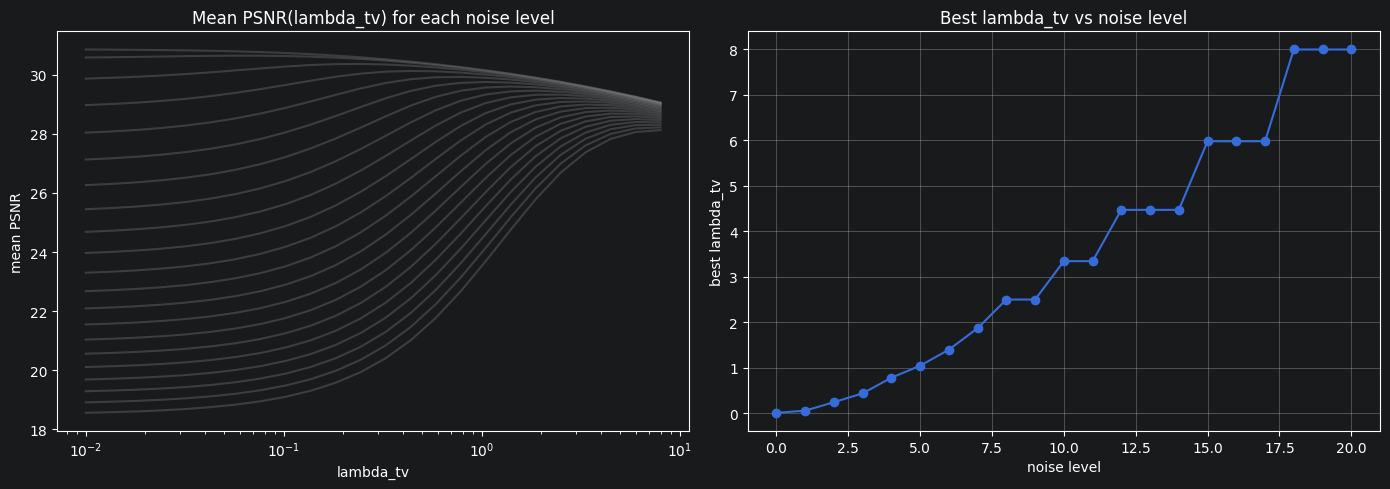

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for noise_level in sorted(df_lambda['noise_level'].unique()):
    part = df_lambda[df_lambda['noise_level'] == noise_level]
    axes[0].plot(part['lambda_tv'], part['mean_psnr'], alpha=0.35, color='gray')

axes[0].set_xscale('log')
axes[0].set_title('Mean PSNR(lambda_tv) for each noise level')
axes[0].set_xlabel('lambda_tv')
axes[0].set_ylabel('mean PSNR')

axes[1].plot(best_by_noise['noise_level'], best_by_noise['lambda_tv'], marker='o')
axes[1].set_title('Best lambda_tv vs noise level')
axes[1].set_xlabel('noise level')
axes[1].set_ylabel('best lambda_tv')
axes[1].grid(True)

plt.tight_layout()
plt.show()


In [16]:
import pandas as pd

lambda_grid = np.linspace(7.0, 14.0, num=12)
noise_levels = list(range(18, 21))

rows = []

for noise_level in noise_levels:
    best_row = None

    for lambda_tv in lambda_grid:
        total_psnr = 0.0

        for kernel_config in KERNELS_BENCHMARK:
            config = {
                'lambda_tv': float(lambda_tv),
                'tau': base_config['tau'],
                'sigma': base_config['sigma'],
                'theta': base_config['theta'],
            }

            kernel = build_kernel(kernel_config)
            blurred = apply_blur(image, kernel)
            noisy_blurred = add_gaussian_noise(blurred, noise_level, seed=42)
            deconvolved = deconvolve_tv(noisy_blurred, kernel, config)

            total_psnr += compute_psnr(image, deconvolved)

        mean_psnr = total_psnr / len(KERNELS_BENCHMARK)

        row = {
            'noise_level': noise_level,
            'lambda_tv': float(lambda_tv),
            'mean_psnr': float(mean_psnr),
        }
        rows.append(row)

        if best_row is None or row['mean_psnr'] > best_row['mean_psnr']:
            best_row = row

    print(
        f"Noise: {noise_level}, "
        f"Best lambda_tv: {best_row['lambda_tv']:.4f}, "
        f"PSNR: {best_row['mean_psnr']:.2f} dB"
    )

df_lambda_refined = pd.DataFrame(rows)
df_lambda_refined.head()


Noise: 18, Best lambda_tv: 7.0000, PSNR: 28.31 dB
Noise: 19, Best lambda_tv: 7.6364, PSNR: 28.22 dB
Noise: 20, Best lambda_tv: 8.2727, PSNR: 28.13 dB


,noise_level,lambda_tv,mean_psnr
0,18,7.000000,28.314038
1,18,7.636364,28.310676
2,18,8.272727,28.299935
3,18,8.909091,28.284220
4,18,9.545455,28.265006


In [17]:
best_refined_by_noise = (
    df_lambda_refined.sort_values(['noise_level', 'mean_psnr'], ascending=[True, False])
    .groupby('noise_level', as_index=False)
    .first()
)

best_refined_by_noise

,noise_level,lambda_tv,mean_psnr
0,18,7.000000,28.314038
1,19,7.636364,28.221028
2,20,8.272727,28.127556


In [19]:
# update best_by_noise with refined results

for noise_level in best_refined_by_noise['noise_level']:
    refined_row = best_refined_by_noise[best_refined_by_noise['noise_level'] == noise_level].iloc[0]
    best_by_noise.loc[best_by_noise['noise_level'] == noise_level, 'lambda_tv'] = refined_row['lambda_tv']
    best_by_noise.loc[best_by_noise['noise_level'] == noise_level, 'mean_psnr'] = refined_row['mean_psnr']

In [20]:
best_by_noise

,noise_level,lambda_tv,mean_psnr
0,0,0.010000,30.853497
1,1,0.057191,30.644256
2,2,0.244588,30.364705
3,3,0.437398,30.128568
4,4,0.782203,29.927000
5,5,1.046022,29.754278
6,6,1.398821,29.600651
7,7,1.870611,29.461030
8,8,2.501525,29.327300
9,9,2.501525,29.212386


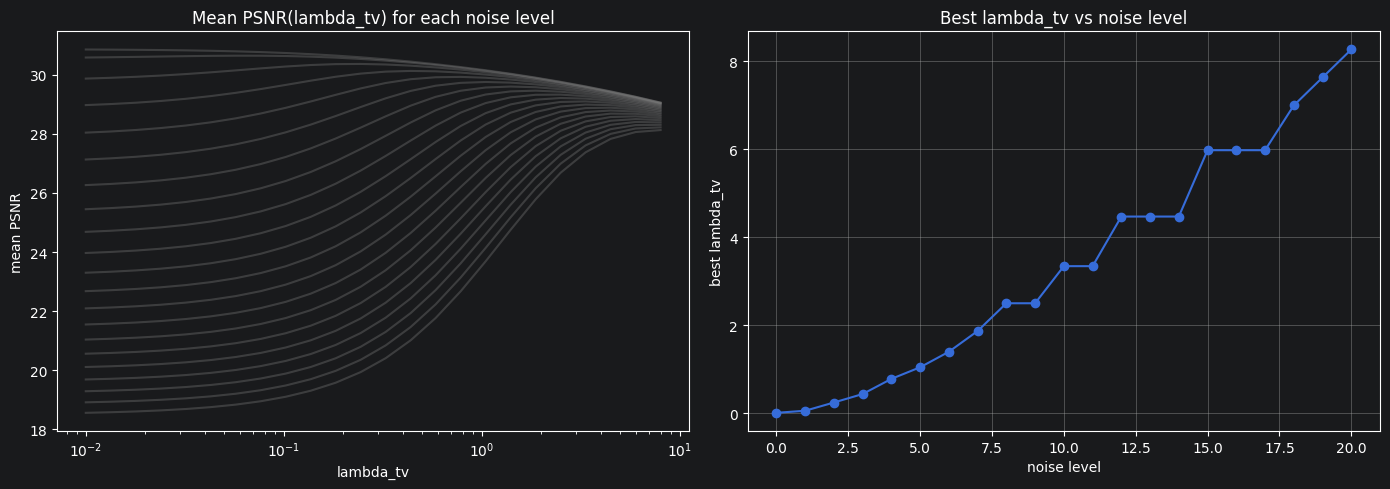

In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for noise_level in sorted(df_lambda['noise_level'].unique()):
    part = df_lambda[df_lambda['noise_level'] == noise_level]
    axes[0].plot(part['lambda_tv'], part['mean_psnr'], alpha=0.35, color='gray')

axes[0].set_xscale('log')
axes[0].set_title('Mean PSNR(lambda_tv) for each noise level')
axes[0].set_xlabel('lambda_tv')
axes[0].set_ylabel('mean PSNR')

axes[1].plot(best_by_noise['noise_level'], best_by_noise['lambda_tv'], marker='o')
axes[1].set_title('Best lambda_tv vs noise level')
axes[1].set_xlabel('noise level')
axes[1].set_ylabel('best lambda_tv')
axes[1].grid(True)

plt.tight_layout()
plt.show()


На графике видно, что существует зависимость между оптимальным значением lambda_tv и noise level, будем аппроксимировать эту зависимость степенной функцией вида lambda_tv(noise) = a * (noise + 1)^b + c, которая обеспечивает положительные значения при нулевом уровне шума и позволяет гибко подстраиваться под рост оптимального lambda_tv при увеличении шума. Подберём параметры a, b, c с помощью curve_fit и посмотрим на качество аппроксимации.

In [22]:
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

x = best_by_noise['noise_level'].to_numpy(dtype=float)
y = best_by_noise['lambda_tv'].to_numpy(dtype=float)

def lambda_power(noise, a, b, c):
    return a * np.power(noise + 1.0, b) + c

params, _ = curve_fit(
    lambda_power,
    x,
    y,
    p0=(0.03, 2.0, 0.0),
    bounds=([0.0, 0.0, -10.0], [100.0, 5.0, 10.0]),
    maxfev=20000,
)

a, b, c = params
print(f"lambda_tv(noise) ~= {a:.6f} * (noise + 1)^{b:.6f} + {c:.6f}")

y_fit = lambda_power(x, *params)
rmse = np.sqrt(np.mean((y - y_fit) ** 2))
print(f"RMSE: {rmse:.6f}")

lambda_tv(noise) ~= 0.111471 * (noise + 1)^1.419654 + -0.253609
RMSE: 0.245734


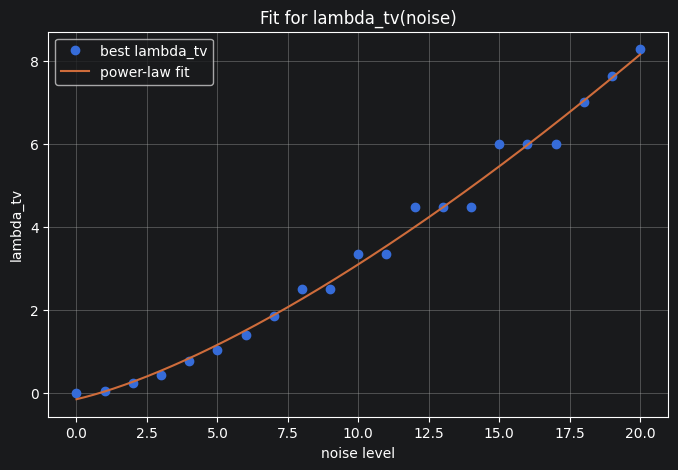

In [23]:
x_plot = np.linspace(x.min(), x.max(), 400)
y_plot = lambda_power(x_plot, *params)

plt.figure(figsize=(8, 5))
plt.plot(x, y, 'o', label='best lambda_tv')
plt.plot(x_plot, y_plot, '-', label='power-law fit')
plt.xlabel('noise level')
plt.ylabel('lambda_tv')
plt.title('Fit for lambda_tv(noise)')
plt.grid(True)
plt.legend()
plt.show()

Получили хорошую наглядную аппроксимацию, которая даже устраняет дефект сетки там, где идут повторяющиеся значения

In [24]:
import pandas as pd

def choose_lambda_tv_from_fit(noise_level: float) -> float:
    value = lambda_power(float(noise_level), *params)
    return float(np.clip(value, 0.01, 8.0))

rows_curve = []

for noise_level in range(21):
    lambda_tv = choose_lambda_tv_from_fit(noise_level)

    for kernel_config in KERNELS_BENCHMARK:
        config = {
            'lambda_tv': lambda_tv,
            'tau': base_config['tau'],
            'sigma': base_config['sigma'],
            'theta': base_config['theta'],
        }

        kernel = build_kernel(kernel_config)
        blurred = apply_blur(image, kernel)
        noisy_blurred = add_gaussian_noise(blurred, noise_level, seed=42)
        deconvolved = deconvolve_tv(noisy_blurred, kernel, config)

        input_psnr = compute_psnr(image, noisy_blurred)
        output_psnr = compute_psnr(image, deconvolved)

        rows_curve.append({
            'noise_level': noise_level,
            'kernel_type': kernel_config['type'],
            'kernel_config': str(kernel_config),
            'lambda_tv': lambda_tv,
            'input_psnr': input_psnr,
            'output_psnr': output_psnr,
            'delta_psnr': output_psnr - input_psnr,
        })

df_curve = pd.DataFrame(rows_curve)
df_curve.head()


,noise_level,kernel_type,kernel_config,lambda_tv,input_psnr,output_psnr,delta_psnr
0,0,gaussian,"{'type': 'gaussian', 'size': 9, 'sigma': 1.0}",0.01,31.867379,35.628569,3.761190
1,0,gaussian,"{'type': 'gaussian', 'size': 15, 'sigma': 2.5}",0.01,27.047260,29.103577,2.056316
2,0,disk,"{'type': 'disk', 'size': 9, 'radius': 2.0}",0.01,30.520811,34.578951,4.058140
3,0,disk,"{'type': 'disk', 'size': 15, 'radius': 4.0}",0.01,27.315401,29.760158,2.444757
4,0,motion,"{'type': 'motion', 'size': 19, 'length': 9.0, ...",0.01,27.302996,30.237999,2.935003


In [25]:
# df_curve vs best df

df_curve_summary = df_curve.groupby('noise_level').agg({
    'input_psnr': 'mean',
    'output_psnr': 'mean',
    'delta_psnr': 'mean',
}).reset_index()

best_summary = best_by_noise[['noise_level', 'mean_psnr']].rename(columns={'mean_psnr': 'best_mean_psnr'})
comparison = pd.merge(df_curve_summary, best_summary, on='noise_level')
comparison['curve_mean_psnr'] = comparison['input_psnr'] + comparison['delta_psnr']

comparison['curve_vs_best'] = comparison['curve_mean_psnr'] - comparison['best_mean_psnr']

print(comparison[['noise_level', 'best_mean_psnr', 'curve_mean_psnr', 'curve_vs_best']])

    noise_level  best_mean_psnr  curve_mean_psnr  curve_vs_best
0             0       30.853497        30.853497       0.000000
1             1       30.644256        30.639447      -0.004809
2             2       30.364705        30.359764      -0.004941
3             3       30.128568        30.121850      -0.006718
4             4       29.927000        29.923124      -0.003876
5             5       29.754278        29.751443      -0.002835
6             6       29.600651        29.599189      -0.001463
7             7       29.461030        29.460875      -0.000155
8             8       29.327300        29.332990       0.005690
9             9       29.212386        29.213225       0.000839
10           10       29.097290        29.100067       0.002776
11           11       28.990826        28.992482       0.001656
12           12       28.884805        28.889270       0.004465
13           13       28.789300        28.789291      -0.000009
14           14       28.684359        2

Видим, что в основном такой переход к непрерывной степенной функции сделал даже лучше качество

для оптимизации других параметров надо понимать, что tau и sigma в primal dual схеме зависят друг от друга - сделаем grid search по обоим параметрам сразу

In [27]:
import pandas as pd

def choose_lambda_tv_from_fit(noise_level: float) -> float:
    value = 0.111471 * (float(noise_level) + 1.0) ** 1.419654 - 0.253609
    return float(np.clip(value, 0.01, 8.0))

noise_levels_probe = [0, 5, 10, 15, 20]
tau_grid = np.linspace(0.1, 1.0, 10)
sigma_grid = np.linspace(0.1, 1.0, 10)

rows_tau_sigma = []

for noise_level in noise_levels_probe:
    lambda_tv = choose_lambda_tv_from_fit(noise_level)
    best_row = None

    for tau in tau_grid:
        for sigma in sigma_grid:
            total_psnr = 0.0

            for kernel_config in KERNELS_BENCHMARK:
                config = {
                    'lambda_tv': lambda_tv,
                    'tau': float(tau),
                    'sigma': float(sigma),
                    'theta': base_config['theta'],
                }

                kernel = build_kernel(kernel_config)
                blurred = apply_blur(image, kernel)
                noisy_blurred = add_gaussian_noise(blurred, noise_level, seed=42)
                deconvolved = deconvolve_tv(noisy_blurred, kernel, config)

                total_psnr += compute_psnr(image, deconvolved)

            mean_psnr = total_psnr / len(KERNELS_BENCHMARK)

            row = {
                'noise_level': noise_level,
                'lambda_tv': lambda_tv,
                'tau': float(tau),
                'sigma': float(sigma),
                'mean_psnr': float(mean_psnr),
            }
            rows_tau_sigma.append(row)

            if best_row is None or row['mean_psnr'] > best_row['mean_psnr']:
                best_row = row

    print(
        f"Noise: {noise_level}, "
        f"lambda_tv: {lambda_tv:.4f}, "
        f"best tau: {best_row['tau']:.3f}, "
        f"best sigma: {best_row['sigma']:.3f}, "
        f"PSNR: {best_row['mean_psnr']:.2f} dB"
    )

df_tau_sigma = pd.DataFrame(rows_tau_sigma)
df_tau_sigma.head()


Noise: 0, lambda_tv: 0.0100, best tau: 1.000, best sigma: 0.100, PSNR: 32.97 dB


KeyboardInterrupt: 

Здесь уже видим, что оптимальные tau и sigma зависят от уровня шума, но при этом их произведение не должно быть слишком большим, иначе алгоритм плохо сходится. Поэтому для более эффективного поиска будем делать рандомизированный перебор по tau и sigma с условием, что их произведение не превышает 0.5, а lambda_tv будет задаваться функцией от уровня шума, которую мы аппроксимировали ранее.

In [28]:
import pandas as pd

def choose_lambda_tv_from_fit(noise_level: float) -> float:
    value = 0.111471 * (float(noise_level) + 1.0) ** 1.419654 - 0.253609
    return float(np.clip(value, 0.01, 8.0))

noise_levels_probe = [0, 5, 10, 15, 20]
n_trials = 20
tau_min, tau_max = 0.1, 1.0
sigma_min, sigma_max = 0.1, 1.0
max_tau_sigma_product = 0.5

rng = np.random.default_rng(42)
rows_random = []

for noise_level in noise_levels_probe:
    lambda_tv = choose_lambda_tv_from_fit(noise_level)
    best_row = None
    trial_id = 0

    while trial_id < n_trials:
        tau = float(rng.uniform(tau_min, tau_max))
        sigma = float(rng.uniform(sigma_min, sigma_max))

        if tau * sigma > max_tau_sigma_product:
            continue

        total_psnr = 0.0

        for kernel_config in KERNELS_BENCHMARK:
            config = {
                'lambda_tv': lambda_tv,
                'tau': tau,
                'sigma': sigma,
                'theta': base_config['theta'],
            }

            kernel = build_kernel(kernel_config)
            blurred = apply_blur(image, kernel)
            noisy_blurred = add_gaussian_noise(blurred, noise_level, seed=42)
            deconvolved = deconvolve_tv(noisy_blurred, kernel, config)

            total_psnr += compute_psnr(image, deconvolved)

        mean_psnr = total_psnr / len(KERNELS_BENCHMARK)

        row = {
            'noise_level': noise_level,
            'lambda_tv': lambda_tv,
            'tau': tau,
            'sigma': sigma,
            'tau_sigma_product': tau * sigma,
            'mean_psnr': float(mean_psnr),
        }
        rows_random.append(row)

        if best_row is None or row['mean_psnr'] > best_row['mean_psnr']:
            best_row = row

        trial_id += 1

    print(
        f"Noise: {noise_level}, "
        f"lambda_tv: {lambda_tv:.4f}, "
        f"best tau: {best_row['tau']:.4f}, "
        f"best sigma: {best_row['sigma']:.4f}, "
        f"tau*sigma: {best_row['tau_sigma_product']:.4f}, "
        f"PSNR: {best_row['mean_psnr']:.2f} dB"
    )

df_random = pd.DataFrame(rows_random)
df_random.head()

Noise: 0, lambda_tv: 0.0100, best tau: 0.8005, best sigma: 0.2752, tau*sigma: 0.2203, PSNR: 32.68 dB
Noise: 5, lambda_tv: 1.1650, best tau: 0.8326, best sigma: 0.2503, tau*sigma: 0.2084, PSNR: 30.34 dB
Noise: 10, lambda_tv: 3.1005, best tau: 0.8045, best sigma: 0.1745, tau*sigma: 0.1403, PSNR: 29.49 dB
Noise: 15, lambda_tv: 5.4559, best tau: 0.5507, best sigma: 0.2295, tau*sigma: 0.1264, PSNR: 28.83 dB
Noise: 20, lambda_tv: 8.0000, best tau: 0.6706, best sigma: 0.1953, tau*sigma: 0.1310, PSNR: 28.32 dB


,noise_level,lambda_tv,tau,sigma,tau_sigma_product,mean_psnr
0,0,0.01,0.796560,0.494991,0.394290,32.672955
1,0,0.01,0.184760,0.978060,0.180706,30.755235
2,0,0.01,0.215302,0.505347,0.108802,30.946196
3,0,0.01,0.433718,0.934088,0.405131,31.866569
4,0,0.01,0.499073,0.304515,0.151975,32.054185


In [29]:
best_random = (
    df_random.sort_values(['noise_level', 'mean_psnr'], ascending=[True, False])
    .groupby('noise_level', as_index=False)
    .first()
)

best_random

,noise_level,lambda_tv,tau,sigma,tau_sigma_product,mean_psnr
0,0,0.010000,0.800545,0.275175,0.220290,32.679486
1,5,1.165015,0.832618,0.250276,0.208384,30.338535
2,10,3.100516,0.804462,0.174457,0.140344,29.487177
3,15,5.455859,0.550667,0.229508,0.126382,28.831724
4,20,8.000000,0.670578,0.195308,0.130969,28.317615


Получили некоторые разумные приближения и поняли, в каких местах лучше искать tau и sigma

In [30]:
baseline_rows = []

for noise_level in noise_levels_probe:
    lambda_tv = choose_lambda_tv_from_fit(noise_level)
    total_psnr = 0.0

    for kernel_config in KERNELS_BENCHMARK:
        config = {
            'lambda_tv': lambda_tv,
            'tau': 0.2,
            'sigma': 0.4,
            'theta': base_config['theta'],
        }

        kernel = build_kernel(kernel_config)
        blurred = apply_blur(image, kernel)
        noisy_blurred = add_gaussian_noise(blurred, noise_level, seed=42)
        deconvolved = deconvolve_tv(noisy_blurred, kernel, config)

        total_psnr += compute_psnr(image, deconvolved)

    baseline_rows.append({
        'noise_level': noise_level,
        'baseline_mean_psnr': total_psnr / len(KERNELS_BENCHMARK),
    })

baseline_random = pd.DataFrame(baseline_rows)

comparison_random = best_random.merge(baseline_random, on='noise_level')
comparison_random['best_minus_baseline'] = (
    comparison_random['mean_psnr'] - comparison_random['baseline_mean_psnr']
)

comparison_random[['noise_level', 'lambda_tv', 'tau', 'sigma', 'tau_sigma_product', 'mean_psnr', 'baseline_mean_psnr', 'best_minus_baseline']]

,noise_level,lambda_tv,tau,sigma,tau_sigma_product,mean_psnr,baseline_mean_psnr,best_minus_baseline
0,0,0.010000,0.800545,0.275175,0.220290,32.679486,30.853497,1.825989
1,5,1.165015,0.832618,0.250276,0.208384,30.338535,29.751443,0.587092
2,10,3.100516,0.804462,0.174457,0.140344,29.487177,29.100067,0.387110
3,15,5.455859,0.550667,0.229508,0.126382,28.831724,28.595689,0.236035
4,20,8.000000,0.670578,0.195308,0.130969,28.317615,28.127912,0.189703


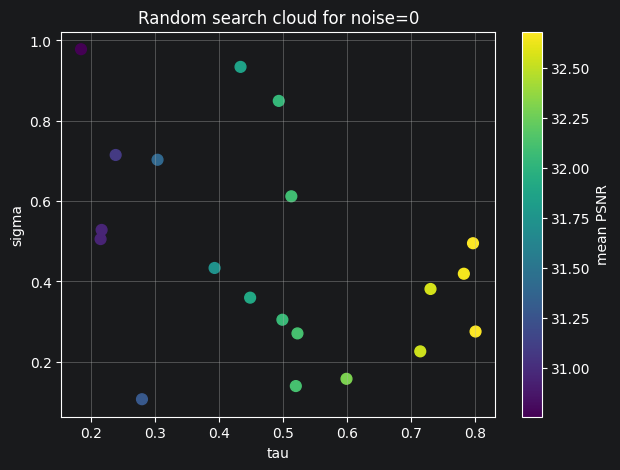

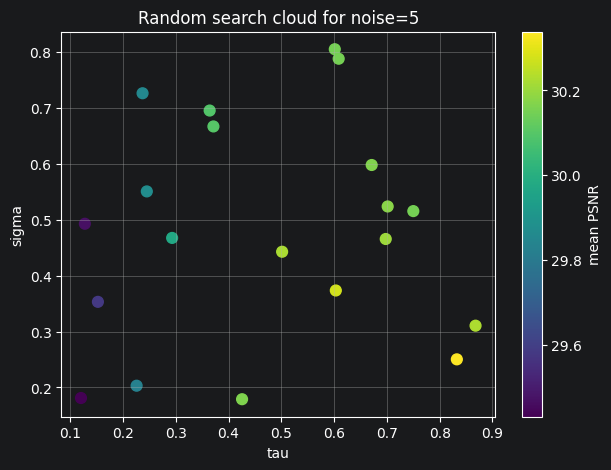

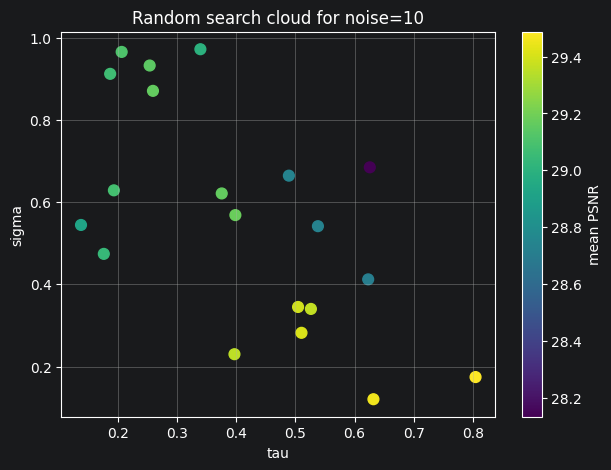

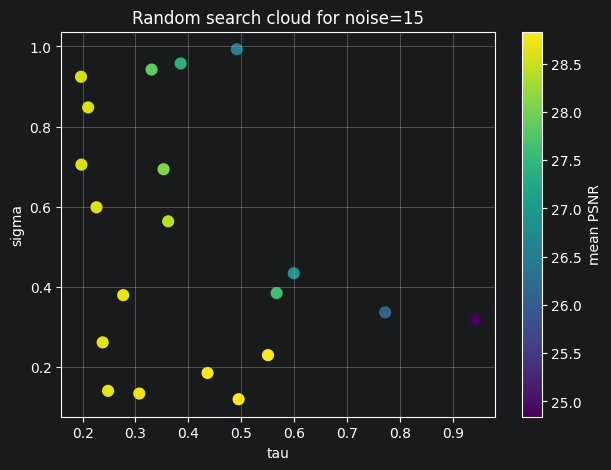

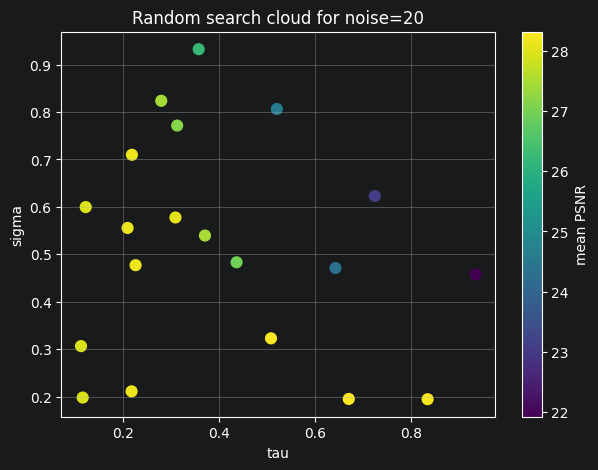

In [32]:
import matplotlib.pyplot as plt

for i, noise_to_plot in enumerate(noise_levels_probe):
    part = df_random[df_random['noise_level'] == noise_to_plot]
    plt.figure(figsize=(7, 5))
    sc = plt.scatter(part['tau'], part['sigma'], c=part['mean_psnr'], cmap='viridis', s=60)
    plt.colorbar(sc, label='mean PSNR')
    plt.xlabel('tau')
    plt.ylabel('sigma')
    plt.title(f'Random search cloud for noise={noise_to_plot}')
    plt.grid(True)
    plt.show()



In [33]:
import pandas as pd

def choose_lambda_tv_from_fit(noise_level: float) -> float:
    value = 0.111471 * (float(noise_level) + 1.0) ** 1.419654 - 0.253609
    return float(np.clip(value, 0.01, 8.0))

candidate_pairs = [
    {'name': 'baseline', 'tau': 0.2, 'sigma': 0.4},
    {'name': 'pair_08_02', 'tau': 0.8, 'sigma': 0.2},
    {'name': 'pair_08_025', 'tau': 0.8, 'sigma': 0.25},
    {'name': 'pair_06_02', 'tau': 0.6, 'sigma': 0.2},
]

rows_pairs = []

for candidate in candidate_pairs:
    total_input_psnr = 0.0
    total_output_psnr = 0.0
    total_cases = 0
    worst_delta = float('inf')

    for noise_level in range(21):
        lambda_tv = choose_lambda_tv_from_fit(noise_level)

        for kernel_config in KERNELS_BENCHMARK:
            config = {
                'lambda_tv': lambda_tv,
                'tau': candidate['tau'],
                'sigma': candidate['sigma'],
                'theta': base_config['theta'],
            }

            kernel = build_kernel(kernel_config)
            blurred = apply_blur(image, kernel)
            noisy_blurred = add_gaussian_noise(blurred, noise_level, seed=42)
            deconvolved = deconvolve_tv(noisy_blurred, kernel, config)

            input_psnr = compute_psnr(image, noisy_blurred)
            output_psnr = compute_psnr(image, deconvolved)
            delta_psnr = output_psnr - input_psnr

            total_input_psnr += input_psnr
            total_output_psnr += output_psnr
            total_cases += 1
            worst_delta = min(worst_delta, delta_psnr)

            rows_pairs.append({
                'name': candidate['name'],
                'noise_level': noise_level,
                'kernel_type': kernel_config['type'],
                'tau': candidate['tau'],
                'sigma': candidate['sigma'],
                'lambda_tv': lambda_tv,
                'input_psnr': input_psnr,
                'output_psnr': output_psnr,
                'delta_psnr': delta_psnr,
            })

    mean_input_psnr = total_input_psnr / total_cases
    mean_output_psnr = total_output_psnr / total_cases
    mean_delta_psnr = mean_output_psnr - mean_input_psnr

    print(
        f"{candidate['name']}: "
        f"tau={candidate['tau']:.3f}, sigma={candidate['sigma']:.3f}, "
        f"mean_delta_psnr={mean_delta_psnr:.4f}, worst_delta_psnr={worst_delta:.4f}"
    )

df_pairs = pd.DataFrame(rows_pairs)
df_pairs.head()

baseline: tau=0.200, sigma=0.400, mean_delta_psnr=4.4271, worst_delta_psnr=2.0519
pair_08_02: tau=0.800, sigma=0.200, mean_delta_psnr=4.9652, worst_delta_psnr=2.4607
pair_08_025: tau=0.800, sigma=0.250, mean_delta_psnr=3.9897, worst_delta_psnr=2.4469
pair_06_02: tau=0.600, sigma=0.200, mean_delta_psnr=4.8909, worst_delta_psnr=2.4792


,name,noise_level,kernel_type,tau,sigma,lambda_tv,input_psnr,output_psnr,delta_psnr
0,baseline,0,gaussian,0.2,0.4,0.01,31.867379,35.628569,3.761190
1,baseline,0,gaussian,0.2,0.4,0.01,27.047260,29.103577,2.056316
2,baseline,0,disk,0.2,0.4,0.01,30.520811,34.578951,4.058140
3,baseline,0,disk,0.2,0.4,0.01,27.315401,29.760158,2.444757
4,baseline,0,motion,0.2,0.4,0.01,27.302996,30.237999,2.935003


In [48]:
import pandas as pd

def choose_lambda_tv_from_fit(noise_level: float) -> float:
    value = 0.111471 * (float(noise_level) + 1.0) ** 1.419654 - 0.253609
    return float(np.clip(value, 0.01, 8.0))

candidate_pairs = [
    {'name': 'pair_12_001', 'tau': 1.2, 'sigma': 0.05},
]

for candidate in candidate_pairs:
    total_input_psnr = 0.0
    total_output_psnr = 0.0
    total_cases = 0
    worst_delta = float('inf')

    for noise_level in range(21):
        lambda_tv = choose_lambda_tv_from_fit(noise_level)

        for kernel_config in KERNELS_BENCHMARK:
            config = {
                'lambda_tv': lambda_tv,
                'tau': candidate['tau'],
                'sigma': candidate['sigma'],
                'theta': base_config['theta'],
            }

            kernel = build_kernel(kernel_config)
            blurred = apply_blur(image, kernel)
            noisy_blurred = add_gaussian_noise(blurred, noise_level, seed=42)
            deconvolved = deconvolve_tv(noisy_blurred, kernel, config)

            input_psnr = compute_psnr(image, noisy_blurred)
            output_psnr = compute_psnr(image, deconvolved)
            delta_psnr = output_psnr - input_psnr

            total_input_psnr += input_psnr
            total_output_psnr += output_psnr
            total_cases += 1
            worst_delta = min(worst_delta, delta_psnr)

            rows_pairs.append({
                'name': candidate['name'],
                'noise_level': noise_level,
                'kernel_type': kernel_config['type'],
                'tau': candidate['tau'],
                'sigma': candidate['sigma'],
                'lambda_tv': lambda_tv,
                'input_psnr': input_psnr,
                'output_psnr': output_psnr,
                'delta_psnr': delta_psnr,
            })

    mean_input_psnr = total_input_psnr / total_cases
    mean_output_psnr = total_output_psnr / total_cases
    mean_delta_psnr = mean_output_psnr - mean_input_psnr

    print(
        f"{candidate['name']}: "
        f"tau={candidate['tau']:.3f}, sigma={candidate['sigma']:.3f}, "
        f"mean_delta_psnr={mean_delta_psnr:.4f}, worst_delta_psnr={worst_delta:.4f}"
    )

df_pairs = pd.DataFrame(rows_pairs)
df_pairs.head()

pair_12_001: tau=1.200, sigma=0.050, mean_delta_psnr=5.0484, worst_delta_psnr=2.4327


,name,noise_level,kernel_type,tau,sigma,lambda_tv,input_psnr,output_psnr,delta_psnr
0,baseline,0,gaussian,0.2,0.4,0.01,31.867379,35.628569,3.761190
1,baseline,0,gaussian,0.2,0.4,0.01,27.047260,29.103577,2.056316
2,baseline,0,disk,0.2,0.4,0.01,30.520811,34.578951,4.058140
3,baseline,0,disk,0.2,0.4,0.01,27.315401,29.760158,2.444757
4,baseline,0,motion,0.2,0.4,0.01,27.302996,30.237999,2.935003


In [49]:
pairs_summary = (
    df_pairs.groupby(['name', 'tau', 'sigma'], as_index=False)
    .agg(
        mean_input_psnr=('input_psnr', 'mean'),
        mean_output_psnr=('output_psnr', 'mean'),
        mean_delta_psnr=('delta_psnr', 'mean'),
        worst_delta_psnr=('delta_psnr', 'min'),
    )
    .sort_values('mean_delta_psnr', ascending=False)
)

pairs_summary


,name,tau,sigma,mean_input_psnr,mean_output_psnr,mean_delta_psnr,worst_delta_psnr
6,pair_12_001,1.20,0.05,24.805564,29.853956,5.048392,2.432736
4,pair_095_01,0.95,0.10,24.805564,29.811709,5.006144,2.448506
5,pair_09_01,0.90,0.10,24.805564,29.800698,4.995134,2.452175
2,pair_08_02,0.80,0.20,24.805564,29.770796,4.965232,2.460669
1,pair_06_02,0.60,0.20,24.805564,29.696496,4.890932,2.479242
0,baseline,0.20,0.40,24.805564,29.232624,4.427060,2.051886
3,pair_08_025,0.80,0.25,24.805564,28.795253,3.989689,2.446923


In [50]:
pairs_by_noise = (
    df_pairs.groupby(['name', 'noise_level'], as_index=False)
    .agg(mean_delta_psnr=('delta_psnr', 'mean'))
)

pairs_by_noise

,name,noise_level,mean_delta_psnr
0,baseline,0,3.048461
1,baseline,1,2.883652
2,baseline,2,2.741679
3,baseline,3,2.718721
4,baseline,4,2.797198
...,...,...,...
142,pair_12_001,16,6.184561
143,pair_12_001,17,6.423513
144,pair_12_001,18,6.654212
145,pair_12_001,19,6.876010


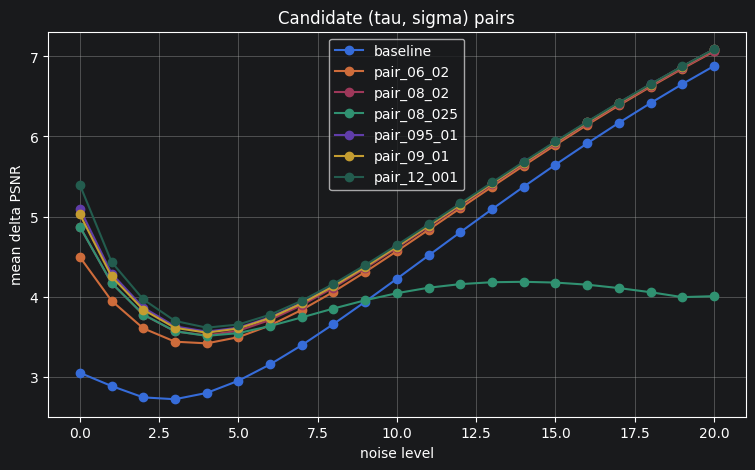

In [51]:
plt.figure(figsize=(9, 5))

for name in pairs_by_noise['name'].unique():
    part = pairs_by_noise[pairs_by_noise['name'] == name]
    plt.plot(part['noise_level'], part['mean_delta_psnr'], marker='o', label=name)

plt.xlabel('noise level')
plt.ylabel('mean delta PSNR')
plt.title('Candidate (tau, sigma) pairs')
plt.grid(True)
plt.legend()
plt.show()


In [47]:
import pandas as pd
from skopt import gp_minimize
from skopt.space import Real

def choose_lambda_tv_from_fit(noise_level: float) -> float:
    value = 0.111471 * (float(noise_level) + 1.0) ** 1.419654 - 0.253609
    return float(np.clip(value, 0.01, 8.0))

noise_bins = [
    {"bin_name": "low", "noise_levels": list(range(0, 6))},    # 0..5
    {"bin_name": "mid", "noise_levels": list(range(6, 12))},   # 6..11
    {"bin_name": "high", "noise_levels": list(range(12, 21))}, # 12..20
]

search_space = [
    Real(0.6, 1.2, name="tau"),
    Real(0.05, 0.3, name="sigma"),
]

bin_results = []
all_eval_rows = []

for bin_spec in noise_bins:
    bin_name = bin_spec["bin_name"]
    bin_noise_levels = bin_spec["noise_levels"]
    eval_rows = []

    def objective(params):
        tau, sigma = params
        total_psnr = 0.0
        total_cases = 0

        for noise_level in bin_noise_levels:
            lambda_tv = choose_lambda_tv_from_fit(noise_level)

            for kernel_config in KERNELS_BENCHMARK:
                config = {
                    "lambda_tv": lambda_tv,
                    "tau": float(tau),
                    "sigma": float(sigma),
                    "theta": base_config["theta"],
                }

                kernel = build_kernel(kernel_config)
                blurred = apply_blur(image, kernel)
                noisy_blurred = add_gaussian_noise(blurred, noise_level, seed=42)
                deconvolved = deconvolve_tv(noisy_blurred, kernel, config)

                total_psnr += compute_psnr(image, deconvolved)
                total_cases += 1

        mean_psnr = total_psnr / total_cases

        eval_rows.append({
            "bin_name": bin_name,
            "tau": float(tau),
            "sigma": float(sigma),
            "tau_sigma_product": float(tau * sigma),
            "mean_psnr": float(mean_psnr),
            "penalized": False,
        })

        return -mean_psnr

    result = gp_minimize(
        objective,
        search_space,
        n_calls=20,
        n_initial_points=8,
        random_state=42,
    )

    best_tau, best_sigma = result.x
    best_mean_psnr = -result.fun

    bin_results.append({
        "bin_name": bin_name,
        "noise_levels": bin_noise_levels,
        "best_tau": float(best_tau),
        "best_sigma": float(best_sigma),
        "best_tau_sigma_product": float(best_tau * best_sigma),
        "best_mean_psnr": float(best_mean_psnr),
    })

    all_eval_rows.extend(eval_rows)

    print(
        f"Bin: {bin_name}, "
        f"noise_levels={bin_noise_levels}, "
        f"best_tau={best_tau:.6f}, "
        f"best_sigma={best_sigma:.6f}, "
        f"tau*sigma={best_tau * best_sigma:.6f}, "
        f"mean_psnr={best_mean_psnr:.6f}"
    )

df_bin_results = pd.DataFrame(bin_results)
df_bin_evals = pd.DataFrame(all_eval_rows)

df_bin_results

Bin: low, noise_levels=[0, 1, 2, 3, 4, 5], best_tau=1.200000, best_sigma=0.050000, tau*sigma=0.060000, mean_psnr=31.544078
Bin: mid, noise_levels=[6, 7, 8, 9, 10, 11], best_tau=1.200000, best_sigma=0.072288, tau*sigma=0.086746, mean_psnr=29.773776


KeyboardInterrupt: 

В целом на этом я остановлюсь уже, можно было еще kernel aware подход рассмотреть, распознав ядро по картинке, для этого даже была программа, но еще больше экспериментов потребуется
Оставляем параметры 1.2 0.05